# Cosmic Microwave Background 1: Measure the temperature of the Universe from its blackbody spectrum

## Authors
Nathaniel Starkman ([@nstarman](https://github.com/nstarman))

Adapted from the [*Coding the Cosmos* Cosmic Microwave Background workshop](https://github.com/Coding-the-Cosmos/notebooks/blob/05479e5b98aaa718cf43f931778a78aa61142c49/workshops/cmb.ipynb) by Louis Branch and Yilun Guan.

## Learning Goals
* Download a data file and read it into a `QTable` with units, using `astropy.utils.data.download_file` and `astropy.table.QTable.read`
* Convert wavenumbers to frequencies with the `astropy.units` spectral equivalency
* Evaluate and plot blackbody spectra with `astropy.modeling.models.BlackBody`
* Fit a model to data with `astropy.modeling.fitting`

## Keywords
units, modeling, model fitting, physics, matplotlib

## Companion Content
* [astropy.modeling documentation](https://docs.astropy.org/en/stable/modeling/)
* [astropy.units equivalencies](https://docs.astropy.org/en/stable/units/equivalencies.html)
* [Make a plot with both redshift and universe age axes](https://learn.astropy.org/tutorials/redshift-plot.html)

## Summary
The cosmic microwave background (CMB) is the oldest light in the Universe. It was released about 380,000 years after the Big Bang, when the Universe had cooled enough for protons and electrons to combine into neutral hydrogen atoms: the Universe became transparent, and light could travel freely through space for the first time. The spectrum of the CMB is the most perfect blackbody ever measured. In this tutorial we will download the spectrum measured by the FIRAS instrument on NASA's COBE satellite, and fit a blackbody model to it to find the temperature of the Universe today. We will then use that temperature to find how hot the Universe was when the CMB was released.

*Note: This is tutorial 1 of 3 in a series on the cosmic microwave background.*

## Imports

In [ ]:
%matplotlib inline
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import Planck18
from astropy.modeling import fitting
from astropy.modeling.models import BlackBody
from astropy.table import QTable
from astropy.utils.data import download_file
from astropy.visualization import quantity_support

# Let matplotlib plot astropy Quantity objects directly
quantity_support();

## Download the FIRAS spectrum

In 1990 the FIRAS instrument on the COBE satellite measured the spectrum of the CMB: how bright it is at each frequency. NASA's [LAMBDA archive](https://lambda.gsfc.nasa.gov/product/cobe/firas_monopole_get.html) hosts the measured spectrum, from Table 4 of [Fixsen et al. (1996)](https://ui.adsabs.harvard.edu/abs/1996ApJ...473..576F), as a text file. We download it with `download_file`, which caches the file so that it is only downloaded once.

In [ ]:
firas_url = "https://lambda.gsfc.nasa.gov/data/cobe/firas/monopole_spec/firas_monopole_spec_v1.txt"
firas_file = download_file(firas_url, cache=True)

The file starts with comment lines (beginning with `#`) that describe five columns of data. The data themselves have no header line, so we tell `QTable.read` to use the `ascii.no_header` format, and give it the column names and units from the file's comments. A `QTable` stores columns that have units as `Quantity` objects.

In [ ]:
firas = QTable.read(
    firas_file,
    format="ascii.no_header",
    names=["wavenumber", "intensity", "residual", "uncertainty", "galaxy"],
    units={
        "wavenumber": u.cm**-1,
        "intensity": u.MJy / u.sr,
        "residual": u.kJy / u.sr,
        "uncertainty": u.kJy / u.sr,
        "galaxy": u.kJy / u.sr,
    },
)
print(firas[:5])

wavenumber intensity residual uncertainty  galaxy 
  1 / cm    MJy / sr kJy / sr   kJy / sr  kJy / sr
---------- --------- -------- ----------- --------
      2.27   200.723      5.0        14.0      4.0
      2.72   249.508      9.0        19.0      3.0
      3.18   293.024     15.0        25.0     -1.0
      3.63    327.77      4.0        23.0     -1.0
      4.08   354.081     19.0        22.0      3.0


We will use three of these columns:

* `wavenumber`: the number of waves per centimeter
* `intensity`: the brightness of the CMB, in megajanskys per steradian (MJy sr$^{-1}$)
* `uncertainty`: the 1$\sigma$ uncertainty on the intensity

## Convert the data to frequencies and matching units

The uncertainty is in kJy sr$^{-1}$, 1000 times smaller than the MJy sr$^{-1}$ of the intensity, so we convert it to match:

In [ ]:
intensity = firas["intensity"]
uncertainty = firas["uncertainty"].to(u.MJy / u.sr)

Frequency is more commonly used than wavenumber. A wavenumber is not a frequency, so a plain unit conversion fails. The [spectral equivalency](https://docs.astropy.org/en/stable/units/equivalencies.html#spectral-units) tells `astropy.units` how wavenumber, wavelength, frequency, and energy relate to one another for light:

In [ ]:
frequency = firas["wavenumber"].to(u.GHz, equivalencies=u.spectral())
print(frequency[:5])

[ 68.05288797  81.54354858  95.33400164 108.82466225 122.31532286] GHz


Now we plot the spectrum. The error bars are drawn, but they are smaller than the points:

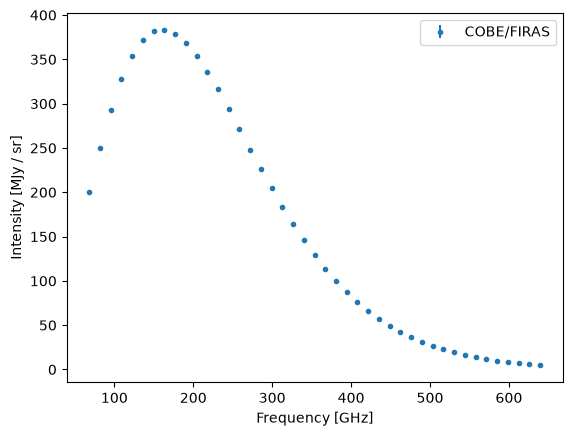

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(frequency, intensity, yerr=uncertainty, fmt="o", markersize=3, label="COBE/FIRAS")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Intensity [MJy / sr]")
ax.legend()
plt.show()

## Plot blackbody spectra at several temperatures

A blackbody is an object that absorbs all light that falls on it. The spectrum of light it emits depends only on its temperature, and is given by Planck's law. The `BlackBody` model computes Planck's law for us. By default, it returns intensities in erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$ sr$^{-1}$; setting its `scale` parameter to 1 MJy sr$^{-1}$ makes it return intensities in the same units as our data.

We draw blackbody spectra for a few temperatures over a smooth grid of frequencies, on top of the data:

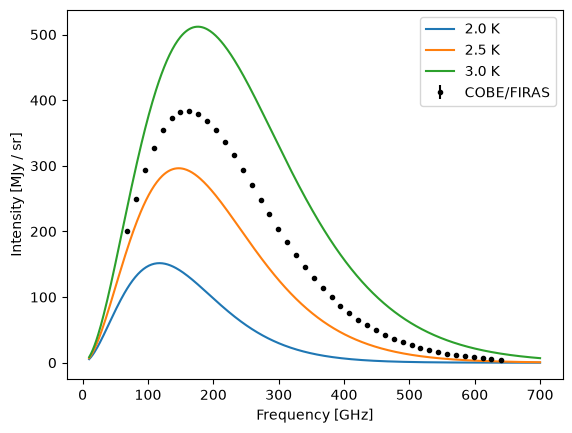

In [ ]:
frequency_grid = np.linspace(10, 700, 500) * u.GHz
temperatures = [2, 2.5, 3] * u.K

fig, ax = plt.subplots()
ax.errorbar(frequency, intensity, yerr=uncertainty, fmt="o", markersize=3, color="k", label="COBE/FIRAS")
for temperature in temperatures:
    blackbody = BlackBody(temperature=temperature, scale=1 * u.MJy / u.sr)
    ax.plot(frequency_grid, blackbody(frequency_grid), label=f"{temperature}")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Intensity [MJy / sr]")
ax.legend()
plt.show()

The data fall between the 2.5 K and 3 K curves, and have the same shape. The CMB is a blackbody, and we can find its temperature by fitting.

## Fit the temperature of the CMB

We start the fit from a guess of 3 K. We fix the `scale` at 1, so that the only free parameter is the temperature; this assumes that the CMB is a perfect blackbody (the exercise at the end of this tutorial tests that assumption).

The fitter finds the temperature that minimizes the difference between the model and the data. Weighting each point by one over its uncertainty makes the most precise measurements count the most. Setting `calc_uncertainties=True` makes the fitter estimate the uncertainty on the fitted temperature too.

In [ ]:
initial_model = BlackBody(temperature=3 * u.K, scale=1 * u.MJy / u.sr)
initial_model.scale.fixed = True

fitter = fitting.TRFLSQFitter(calc_uncertainties=True)
cmb_model = fitter(initial_model, frequency, intensity, weights=1 / uncertainty)

cmb_temperature = cmb_model.temperature.quantity
cmb_temperature_uncertainty = cmb_model.stds["temperature"] * u.K
print(f"CMB temperature: {cmb_temperature:.6f} ± {cmb_temperature_uncertainty:.6f}")

CMB temperature: 2.725015 K ± 0.000008 K


The temperature of the Universe today is 2.725 K, less than three degrees above absolute zero.

<div class="alert alert-info">
The <code>intensity</code> column of this file is the sum of a 2.725 K blackbody and the residuals that the FIRAS team measured (see the comments at the top of the file), so our fit recovers their temperature. What the fit shows is how well a single blackbody describes the data. The FIRAS team measured the temperature itself by calibrating the instrument, and quotes 2.725 ± 0.001 K (<a href="https://ui.adsabs.harvard.edu/abs/2002ApJ...581..817F">Fixsen & Mather 2002</a>). The much smaller uncertainty from our fit reflects only the scatter of the residuals.
</div>

The `Planck18` cosmology in `astropy.cosmology` uses a later, more precise measurement ([Fixsen 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...707..916F)), which agrees with the FIRAS value:

In [ ]:
print(f"Planck18 CMB temperature: {Planck18.Tcmb0}")

Planck18 CMB temperature: 2.7255 K


To see how good the fit is, we plot the data with the fitted model, and the residuals: the data minus the model. We convert the residuals to kJy sr$^{-1}$ so that they are easier to read.

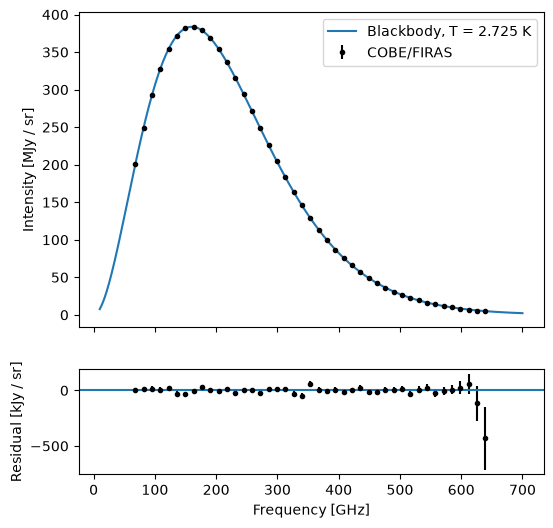

In [ ]:
residuals = (intensity - cmb_model(frequency)).to(u.kJy / u.sr)

fig, (ax_spectrum, ax_residuals) = plt.subplots(2, 1, sharex=True, height_ratios=[3, 1], figsize=(6, 6))
ax_spectrum.errorbar(frequency, intensity, yerr=uncertainty, fmt="o", markersize=3, color="k", label="COBE/FIRAS")
ax_spectrum.plot(frequency_grid, cmb_model(frequency_grid), label=f"Blackbody, T = {cmb_temperature:.3f}")
ax_spectrum.set_ylabel("Intensity [MJy / sr]")
ax_spectrum.legend()

ax_residuals.errorbar(frequency, residuals, yerr=uncertainty.to(u.kJy / u.sr), fmt="o", markersize=3, color="k")
ax_residuals.axhline(0, color="C0")
ax_residuals.set_xlabel("Frequency [GHz]")
ax_residuals.set_ylabel("Residual [kJy / sr]")
plt.show()

The residuals scatter around zero within their error bars. Apart from the two highest-frequency points, which have the largest error bars, they are all smaller than about 60 kJy sr$^{-1}$. The spectrum itself peaks at almost 400,000 kJy sr$^{-1}$, so the CMB matches a blackbody to about one part in ten thousand.

## Find the peak of the spectrum

Hotter objects glow at shorter wavelengths: a heated piece of metal glows first red, then white. Wien's displacement law makes this precise. A blackbody at temperature $T$ is brightest at the wavelength

$$\lambda_\mathrm{max} = \frac{b}{T},$$

where $b \approx 2.898 \times 10^{-3}$ m K is Wien's displacement constant. The `BlackBody` model computes $\lambda_\mathrm{max}$ for us:

In [ ]:
cmb_peak_wavelength = cmb_model.lambda_max
print(f"CMB peak wavelength: {cmb_peak_wavelength.to(u.mm):.3f}")
print(f"Wien's displacement constant: {(cmb_peak_wavelength * cmb_temperature).to(u.m * u.K):.4e}")

CMB peak wavelength: 1.063 mm
Wien's displacement constant: 2.8978e-03 K m


The CMB is brightest at a wavelength of about 1 mm. Light with wavelengths between about 1 mm and 1 m is called microwave light, which is where the cosmic microwave background gets its name.

<div class="alert alert-info">
Our plots show the intensity per unit <em>frequency</em>, and that spectrum peaks at a different place: <code>cmb_model.nu_max</code> is 160 GHz, while a wavelength of 1.06 mm corresponds to 282 GHz. Both are correct; they describe the same light in different units.
</div>

In [ ]:
cmb_peak_frequency = cmb_model.nu_max.to(u.GHz)
print(f"CMB peak frequency: {cmb_peak_frequency:.1f}")
print(f"Frequency of the peak wavelength: {cmb_peak_wavelength.to(u.GHz, equivalencies=u.spectral()):.1f}")

CMB peak frequency: 160.2 GHz
Frequency of the peak wavelength: 281.9 GHz


## Find the temperature of the Universe when the CMB was released

As the Universe expands, the light of the CMB is stretched. Light emitted at redshift $z$ reaches us with its wavelength stretched by a factor of $(1 + z)$. Stretching every wavelength of a blackbody spectrum by the same factor gives another blackbody spectrum, with a temperature lower by that factor:

$$T(z) = T_0 \, (1 + z),$$

where $T_0$ is the temperature we measure today. The CMB was released at a redshift of about 1100 (see the [redshift-plot tutorial](https://learn.astropy.org/tutorials/redshift-plot.html) to relate redshift to the age of the Universe).

In [ ]:
z_release = 1100
release_model = BlackBody(temperature=cmb_temperature * (1 + z_release))

release_temperature = release_model.temperature.quantity
release_peak_wavelength = release_model.lambda_max.to(u.um)
print(f"Temperature when the CMB was released: {release_temperature:.0f}")
print(f"Peak wavelength when the CMB was released: {release_peak_wavelength:.2f}")

Temperature when the CMB was released: 3000 K
Peak wavelength when the CMB was released: 0.97 um


When the CMB was released, the Universe was 3000 K: about as hot as the surface of a cool red star. Its light peaked at about 1 μm, just beyond the red end of the visible spectrum, and the Universe glowed a dull orange-red. Over 13.8 billion years of expansion, that light has been stretched by a factor of 1100 into the microwaves.

We can see this by plotting the spectrum at release against wavelength, and shading the range of wavelengths that our eyes can see. To plot intensity per unit wavelength, we give the `scale` parameter units per wavelength:

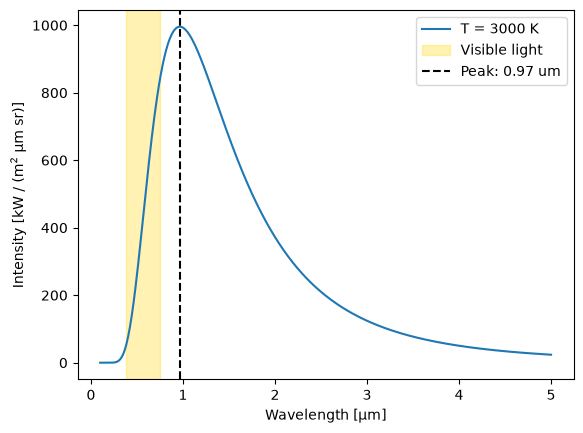

In [ ]:
wavelength_grid = np.linspace(0.1, 5, 500) * u.um
release_model_per_wavelength = BlackBody(temperature=release_temperature, scale=1 * u.kW / (u.m**2 * u.um * u.sr))

fig, ax = plt.subplots()
ax.plot(wavelength_grid, release_model_per_wavelength(wavelength_grid), label=f"T = {release_temperature:.0f}")
ax.axvspan(0.38 * u.um, 0.75 * u.um, color="gold", alpha=0.3, label="Visible light")
ax.axvline(release_peak_wavelength, color="k", linestyle="--", label=f"Peak: {release_peak_wavelength:.2f}")
ax.set_xlabel("Wavelength [μm]")
ax.set_ylabel("Intensity [kW / (m$^2$ μm sr)]")
ax.legend()
plt.show()

In the [next tutorial](2_CMB-Sky-Map.ipynb), we will look at how the temperature of the CMB varies across the sky.

## Exercise

1. Free the `scale` parameter by setting `initial_model.scale.fixed = False`, and fit again. How close to 1 is the fitted scale (`cmb_model.scale`), and what is its uncertainty (`cmb_model.stds["scale"]`)? A scale of exactly 1 means that the CMB emits exactly as much light as a perfect blackbody at its temperature.
2. The first galaxies formed at a redshift of about 10. What was the temperature of the CMB then, and at what wavelength did its spectrum peak?